<img src="https://upload.wikimedia.org/wikipedia/commons/b/b0/Logo_Universidad_Polit%C3%A9cnica_Salesiana_del_Ecuador.png" alt="logo universidad" width="550" height="150">

### Materia Vision por Computador

### Practica 4 — Segmentacion de herramientas con YOLO26

---

**Integrantes:** Paúl Sebastián Naspud, Jennyfer Camila Ramírez

**Fecha de Entrega:**

---


Objetivo: entrenar una red **YOLO26** para segmentacion de instancias
sobre el dataset *Tools Segmentation* (hammer, screw, wrench), capturar imagenes desde una webcam
para probar el modelo, y comparar el rendimiento de inferencia entre **GPU** y **CPU**.




## 0. Verificar entorno GPU/CPU disponible

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("Sin GPU asignada. Este entorno correra en modo CPU.")
    print("En Colab: Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > T4 GPU.")


PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4
Wed Jul  8 01:19:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |              

## 1. Instalar dependencias

In [2]:
!pip install -q -U roboflow ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.8 MB/s eta 0:00:00


## 2. Descarga del dataset desde Roboflow

El dataset se descarga mediante la API de Roboflow, empleando las credenciales del proyecto. El
identificador del proyecto (`slug`) corresponde a la URL pública del dataset:
`https://universe.roboflow.com/paul-space-qcfcl/tools-segmentation-f2nhg-tf2cd`.


In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="t87DRxOynZJMDJVpZltW")
project = rf.workspace("paul-space-qcfcl").project("tools-segmentation-f2nhg-tf2cd")
dataset = project.version(1).download("coco-segmentation")

DATASET_DIR = dataset.location
print("Dataset descargado en:", DATASET_DIR)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Tools-segmentation-1 in coco-segmentation:: 100%|██████████| 3101/3101 [00:00<00:00, 5260.53it/s]

Dataset descargado en: /content/Tools-segmentation-1


## 3. Exploracion del dataset

Se listan las clases anotadas (`hammer`, `screw`, `wrench`), el numero de imagenes y anotaciones
disponibles en el split de entrenamiento, y se visualiza un ejemplo con sus poligonos de
segmentacion superpuestos.


In [4]:
import json
import os

splits = [s for s in ("train", "valid", "test") if os.path.isdir(os.path.join(DATASET_DIR, s))]
print("Splits disponibles:", splits)

with open(os.path.join(DATASET_DIR, "train", "_annotations.coco.json")) as f:
    coco_train = json.load(f)

# la categoria 0 ("workshop-tools") es la supercategoria del export de Roboflow y no tiene instancias propias
categories = {c["id"]: c["name"] for c in coco_train["categories"] if c["name"] != "workshop-tools"}

print("Clases:", categories)
print("Imagenes en train:", len(coco_train["images"]))
print("Anotaciones en train:", len(coco_train["annotations"]))


Splits disponibles: ['train', 'test']
Clases: {1: 'hammer', 2: 'pliers', 3: 'screw', 4: 'wrench'}
Imagenes en train: 2709
Anotaciones en train: 5200


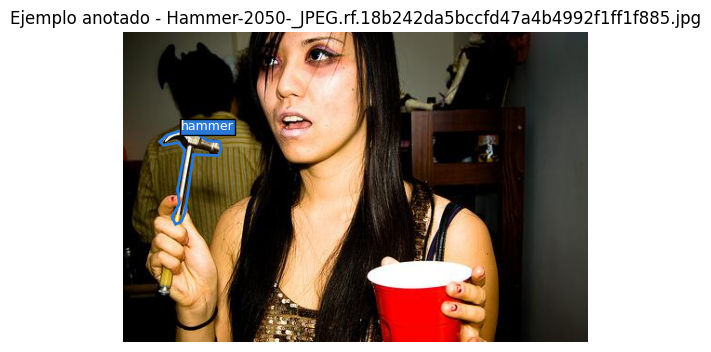

In [5]:
import random

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

img_info = random.choice(coco_train["images"])
img_path = os.path.join(DATASET_DIR, "train", img_info["file_name"])
anns = [a for a in coco_train["annotations"] if a["image_id"] == img_info["id"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Image.open(img_path))
for ann in anns:
    for poly in ann["segmentation"]:
        pts = list(zip(poly[0::2], poly[1::2]))
        ax.add_patch(patches.Polygon(pts, closed=True, fill=False, edgecolor="#2a78d6", linewidth=2))
    label = categories.get(ann["category_id"], "?")
    x, y = ann["segmentation"][0][0], ann["segmentation"][0][1]
    ax.text(x, y, label, color="white", fontsize=9, bbox=dict(facecolor="#2a78d6", pad=1))

ax.set_title(f"Ejemplo anotado - {img_info['file_name']}")
ax.axis("off")
plt.show()


## 4. Conversion de anotaciones COCO-Segmentation al formato YOLO-Segmentation

Ultralytics entrena con etiquetas en formato YOLO (un archivo `.txt` por imagen, con poligonos
normalizados entre 0 y 1), no directamente con el JSON de COCO exportado por Roboflow. Esta seccion
convierte cada split descargado y construye la estructura `images/<split>` + `labels/<split>` que
requiere Ultralytics.


In [6]:
import shutil
from pathlib import Path

YOLO_ROOT = Path("dataset_yolo")


def coco_seg_to_yolo(coco_json_path, images_src_dir, images_dst_dir, labels_dst_dir, class_id_map):
    images_dst_dir = Path(images_dst_dir)
    labels_dst_dir = Path(labels_dst_dir)
    images_dst_dir.mkdir(parents=True, exist_ok=True)
    labels_dst_dir.mkdir(parents=True, exist_ok=True)

    with open(coco_json_path) as f:
        coco = json.load(f)

    anns_by_image = {}
    for ann in coco["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    for img in coco["images"]:
        w, h = img["width"], img["height"]
        file_name = img["file_name"]
        stem = Path(file_name).stem

        src_img = Path(images_src_dir) / file_name
        dst_img = images_dst_dir / file_name
        if src_img.exists() and not dst_img.exists():
            shutil.copy(src_img, dst_img)

        lines = []
        for ann in anns_by_image.get(img["id"], []):
            cat_id = ann["category_id"]
            seg = ann.get("segmentation")
            if cat_id not in class_id_map or not seg or not isinstance(seg, list):
                continue
            cls = class_id_map[cat_id]
            for poly in seg:
                if len(poly) < 6:
                    continue
                norm = [
                    f"{(poly[i] / w if i % 2 == 0 else poly[i] / h):.6f}"
                    for i in range(len(poly))
                ]
                lines.append(f"{cls} " + " ".join(norm))

        (labels_dst_dir / f"{stem}.txt").write_text("\n".join(lines))

    return len(coco["images"])


class_ids_sorted = sorted(categories.keys())
class_id_map = {cid: idx for idx, cid in enumerate(class_ids_sorted)}
class_names = [categories[cid] for cid in class_ids_sorted]
print("Mapa de clases COCO -> YOLO:", class_id_map)
print("Nombres de clase:", class_names)

split_map = {"train": "train", "valid": "val", "test": "test"}

for split in splits:
    coco_json = os.path.join(DATASET_DIR, split, "_annotations.coco.json")
    n = coco_seg_to_yolo(
        coco_json_path=coco_json,
        images_src_dir=os.path.join(DATASET_DIR, split),
        images_dst_dir=YOLO_ROOT / "images" / split_map[split],
        labels_dst_dir=YOLO_ROOT / "labels" / split_map[split],
        class_id_map=class_id_map,
    )
    print(f"{split}: {n} imagenes convertidas")


Mapa de clases COCO -> YOLO: {1: 0, 2: 1, 3: 2, 4: 3}
Nombres de clase: ['hammer', 'pliers', 'screw', 'wrench']
train: 2709 imagenes convertidas
test: 388 imagenes convertidas


In [7]:
# Si el export de Roboflow no trae split "valid" (como el descargado localmente, que solo trae
# train/test), se reserva un 15% de train para validacion. El split "test" se deja intacto como
# conjunto de evaluacion final, sin usarlo durante el entrenamiento.
if "valid" not in splits:
    random.seed(42)
    train_images = list((YOLO_ROOT / "images" / "train").glob("*"))
    n_val = max(1, int(len(train_images) * 0.15))
    val_images = random.sample(train_images, n_val)

    (YOLO_ROOT / "images" / "val").mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / "val").mkdir(parents=True, exist_ok=True)

    for img_path in val_images:
        label_path = YOLO_ROOT / "labels" / "train" / f"{img_path.stem}.txt"
        shutil.move(str(img_path), YOLO_ROOT / "images" / "val" / img_path.name)
        if label_path.exists():
            shutil.move(str(label_path), YOLO_ROOT / "labels" / "val" / label_path.name)

    print(f"Se separaron {n_val} imagenes de train para validacion (val).")


Se separaron 406 imagenes de train para validacion (val).


In [8]:
import yaml

data_yaml = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "nc": len(class_names),
    "names": class_names,
}
if (YOLO_ROOT / "images" / "test").exists():
    data_yaml["test"] = "images/test"

with open(YOLO_ROOT / "data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print((YOLO_ROOT / "data.yaml").read_text())


path: /content/dataset_yolo
train: images/train
val: images/val
nc: 4
names:
- hammer
- pliers
- screw
- wrench
test: images/test



## 5. Definicion del modelo — Transfer Learning con YOLO26

Se parte de los pesos `yolo26n-seg.pt`, preentrenados en COCO, en lugar de entrenar desde cero. La
variante *nano* (`n`) es la mas liviana en computo; la variante *small* (`yolo26s-seg.pt`) ofrece
mayor precision a costa de un mayor tiempo de entrenamiento e inferencia.


In [9]:
from ultralytics import YOLO

MODEL_WEIGHTS = "yolo26n-seg.pt"
model = YOLO(MODEL_WEIGHTS)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 6. Entrenamiento

In [10]:
device = 0 if torch.cuda.is_available() else "cpu"
print("Entrenando en device:", device)

train_results = model.train(
    data=str(YOLO_ROOT / "data.yaml"),
    epochs=60,
    imgsz=640,
    batch=16,
    device=device,
    patience=15,
    project="runs_practica4",
    name="yolo26n_seg_tools",
    pretrained=True,
)


Entrenando en device: 0
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_seg_tools, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

## 7. Validacion y metricas

In [11]:
metrics = model.val(data=str(YOLO_ROOT / "data.yaml"))

print("mAP50-95 :", metrics.seg.map)
print("mAP50    :", metrics.seg.map50)
print("mAP50-95 :   ", metrics.box.map)
print("mAP50    :   ", metrics.box.map50)


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,664 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 605.3±425.4 MB/s, size: 20.5 KB)
val: Scanning /content/dataset_yolo/labels/val.cache... 406 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 406/406 100.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 3.4it/s 7.6s
                   all        406        772      0.896      0.689      0.791      0.693      0.897      0.691       0.79      0.604
                hammer        225        362       0.88      0.903      0.947      0.828      0.875      0.898      0.943      0.699
                pliers          7         10      0.984        0.3      0.471      0.413      0.984        0.3      0.471      0.335
                 screw         66       

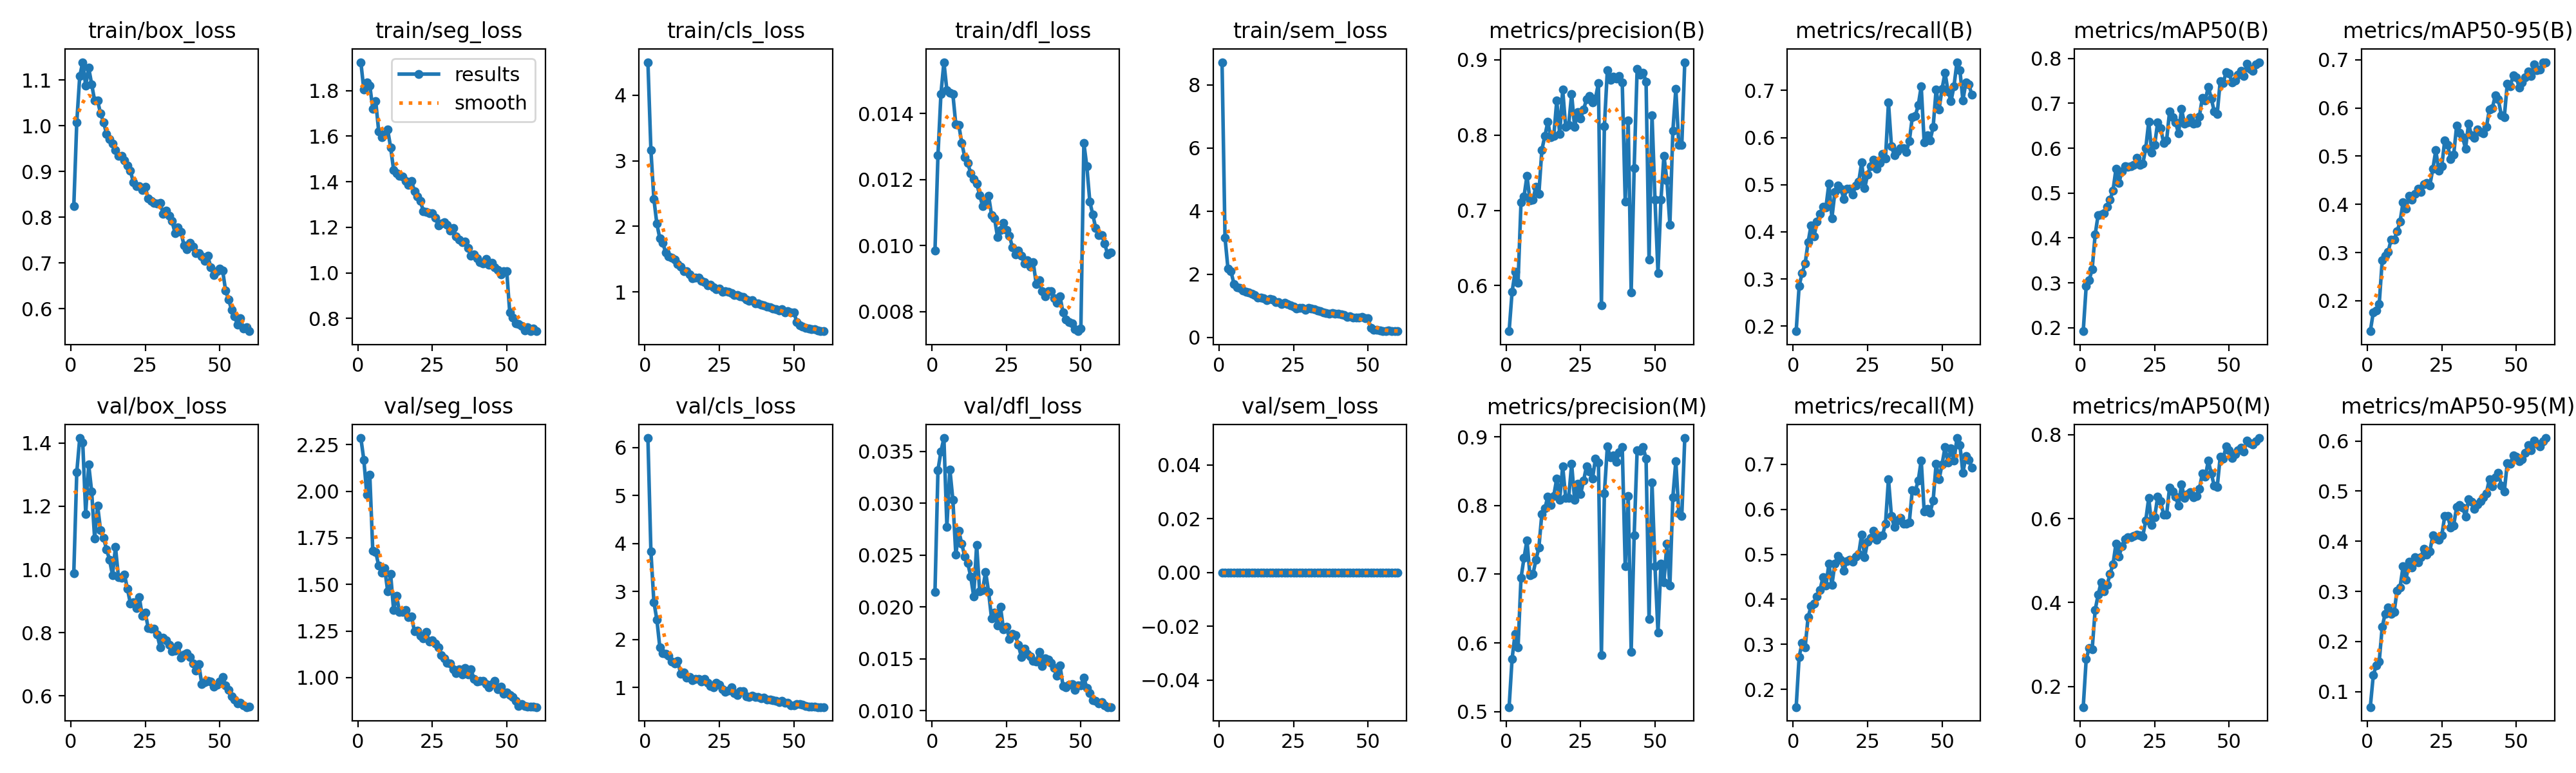

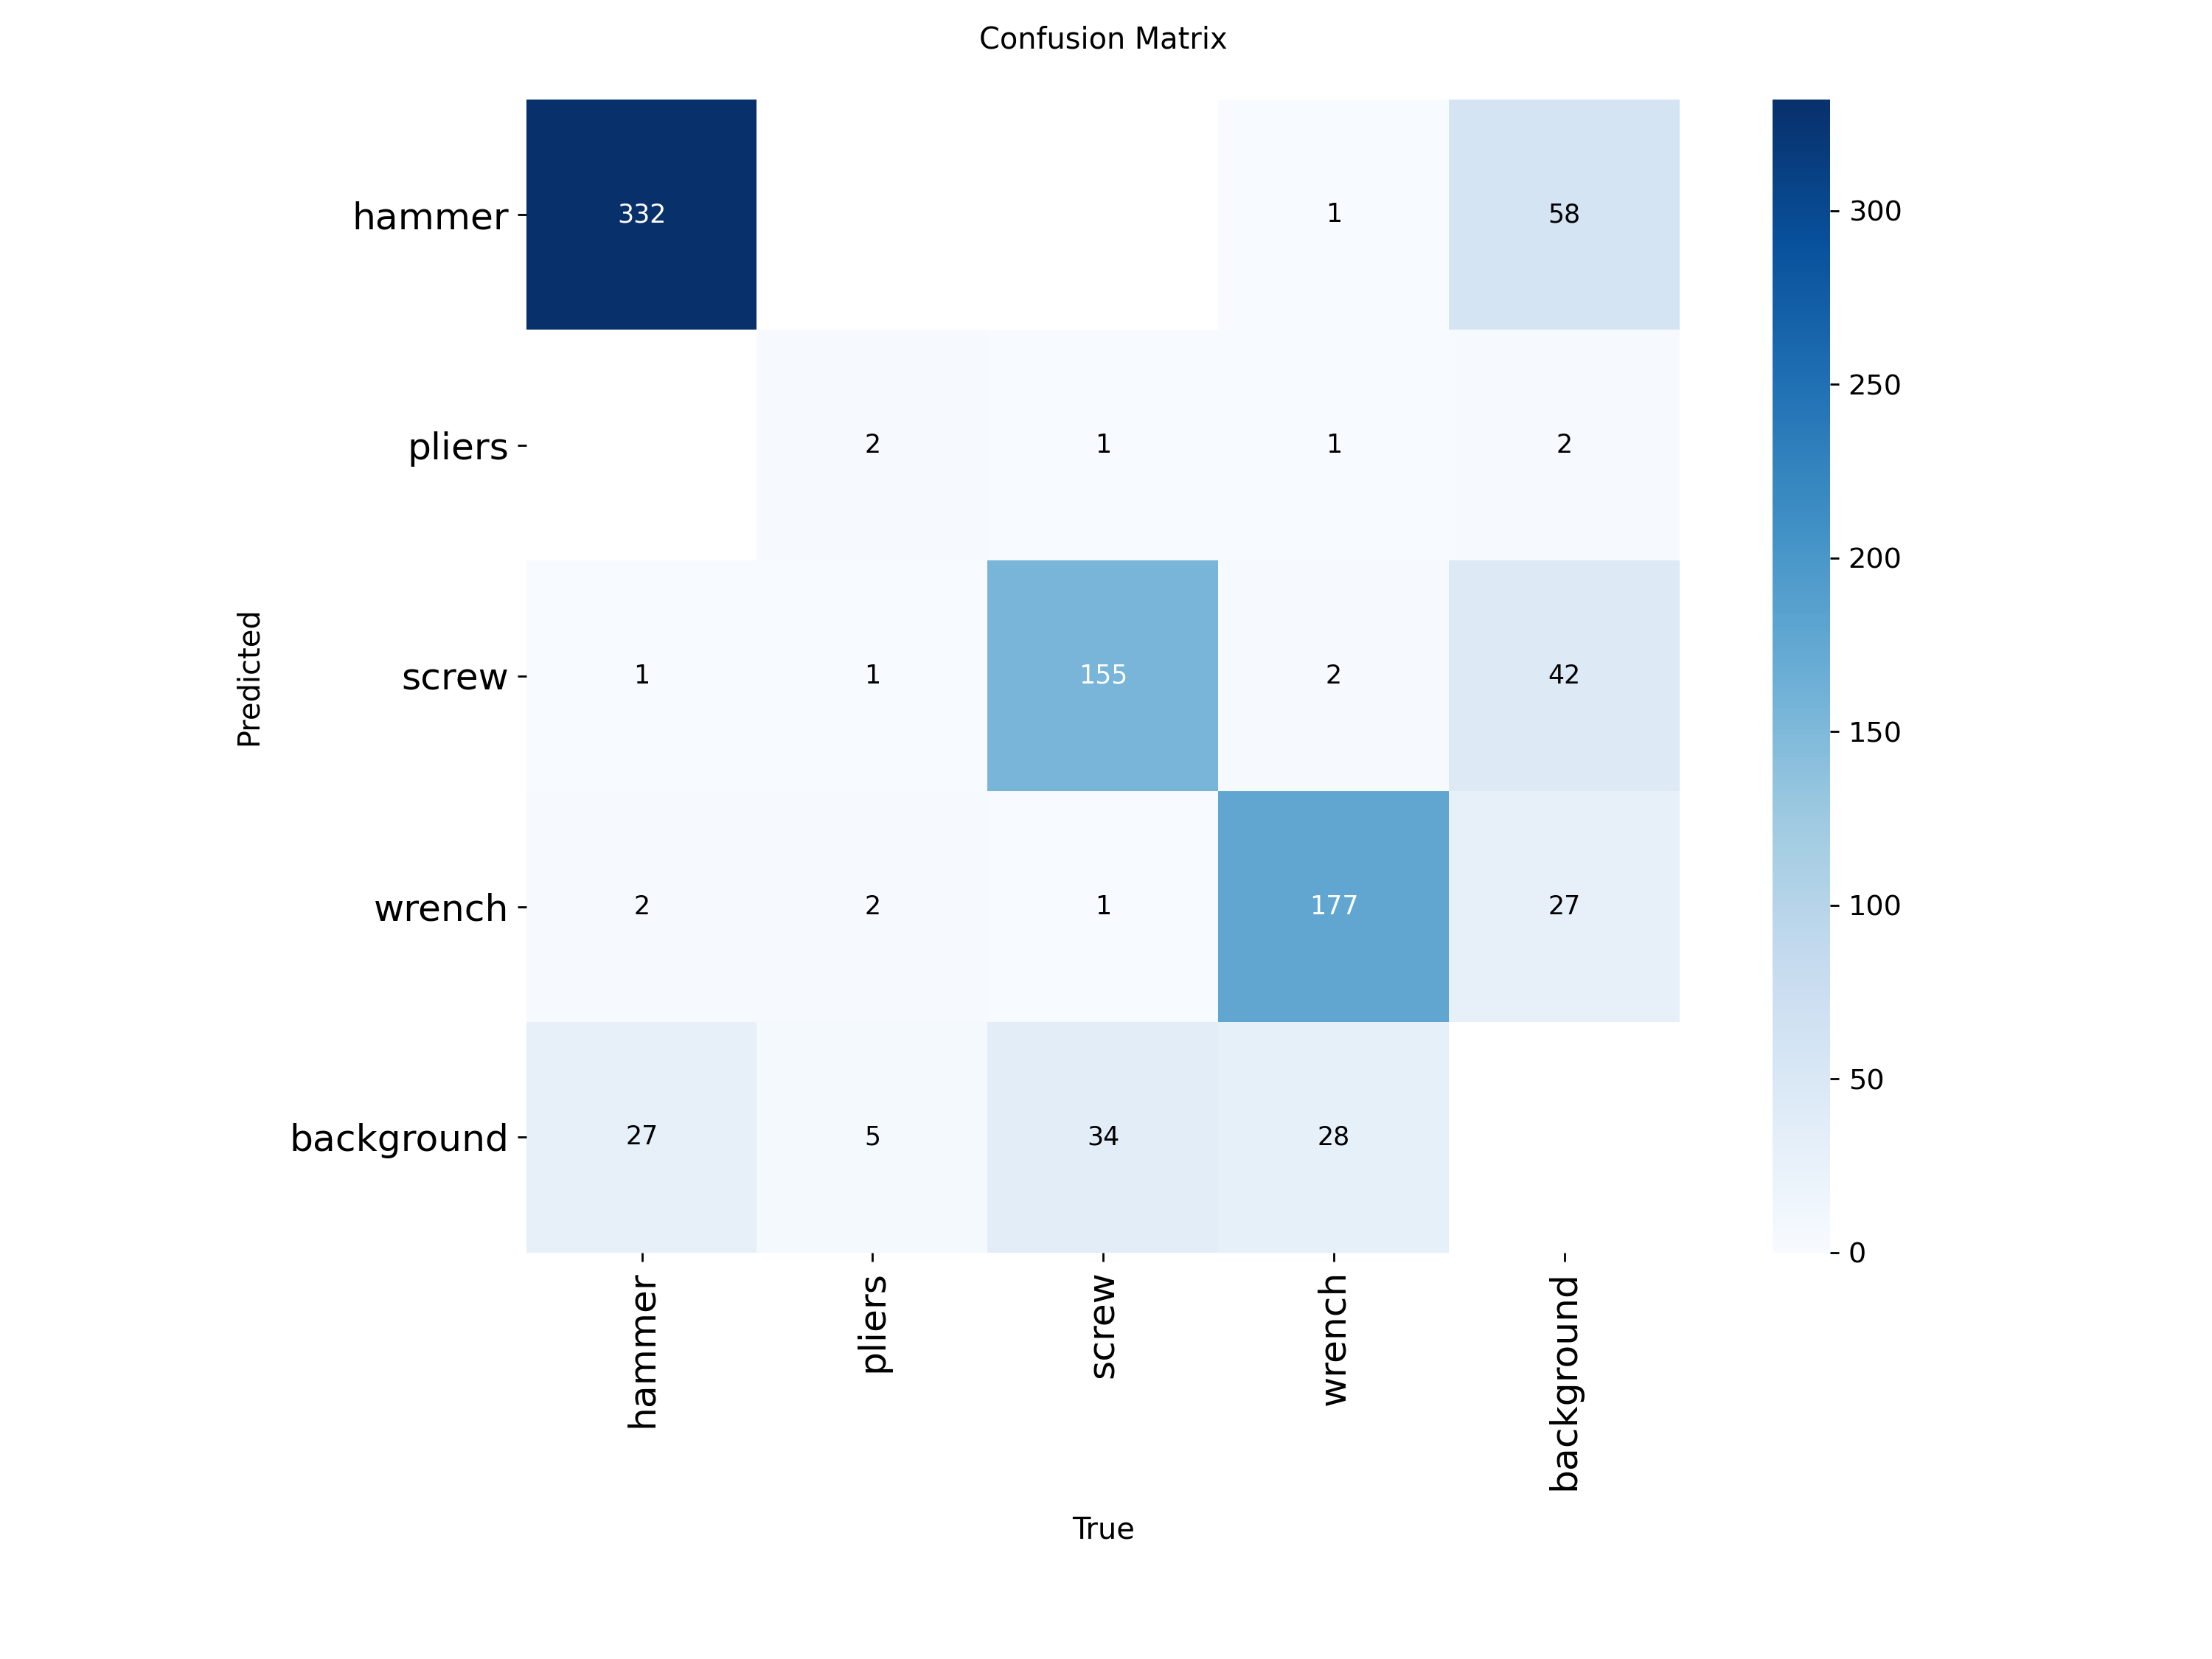

In [12]:
from pathlib import Path

from IPython.display import Image as IPImage
from IPython.display import display

run_dir = Path(model.trainer.save_dir)
display(IPImage(filename=str(run_dir / "results.png")))
display(IPImage(filename=str(run_dir / "confusion_matrix.png")))


## 8. Exportacion del modelo entrenado

El modelo se exporta al formato ONNX, util para inferencia exclusivamente en CPU (por ejemplo en
el Laboratorio de Computo 8, sin depender de Colab ni de Roboflow), y se descargan los pesos
`best.pt`.


In [19]:
onnx_path = model.export(format="onnx")
print("Modelo exportado a:", onnx_path)

from google.colab import files

files.download(str(best_weights))


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 215ms
Prepared 4 packages in 1.76s
Installed 4 packages in 252ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.3s, saved as '/content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.onnx' (10.6 MB)

Export complete (5.7s)
Results saved to /content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.onnx
Predict:         yolo predict task=segment model=/content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.onnx imgsz=640 data=dataset_yolo/data.yaml  
Visualize:       https://netron.app
Modelo exportado a: /content/runs/segment/runs_practica4/yolo26n_seg_tools/weights/best.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>